## Script to run inference on our RDM models 

Notes for reproducibility:
- File paths in cell 2 are absolute, so they should be changed to wherever RDMs are kept
- Partial correlation functions are messy, but unfortunately necessary due to no similar function in rsatoolbox. A better way would be to use linear regression, but as we have 4x4 RDMs this is difficult.
- Please feel free to reach out to the first author for script clarification :)

... and happy RSA!

In [190]:
clear all

In [191]:
analysis_options = ['main', 'main_control', 'reliable_control', 'rt_control', 'rtlog_control', 'eye_control', 'eye_control_affordance']
analysis = analysis_options[6] # identify analysis approach

models_of_interest = ['affordance'] # set models to plot and run stat tests based on. in all cases except eye control this is 'affordance'


print(f'======       Running analysis "{analysis}"       ======')

append_str = '_stickfunction5vis' # identify correct files

if analysis == 'main': # primary analyses without excluding other possible models 
        models = ['affordance'] 
        regions = ['Entorhinal-right', 'Entorhinal-left']

elif analysis == 'main_control':  # secondary analyses excluding other possible models and regions
        models = ['affordance', 'affordance_magnitude', 'link_distance']
        regions = ['Entorhinal-right', 'Entorhinal-left', # primary region to test
           'Hippocampus-right', 'Hippocampus-left', # MTL controls 1
           'PhG-right', 'PhG-left', # MTL controls 2
           '4a_4p-left', '4a_4p-right'] # motor cortex controls

elif analysis == 'rt_control': # control analyses using RT
        models = ['affordance', 'affordance_magnitude', 'link_distance', 'rt'] 
        regions = ['Entorhinal-right']

elif analysis == 'reliable_control':  # secondary analyses using reliability-selected regions
        models = ['affordance', 'affordance_magnitude', 'link_distance', 'rt']
        regions = ['rel2Entorhinal-right', 'rel2Entorhinal-left']

elif analysis == 'rtlog_control': # control analysis using log-transformed RT
        models = ['affordance', 'affordance_magnitude', 'link_distance', 'rt_log'] 
        regions = ['Entorhinal-right']
 
elif analysis == 'eye_control': # control analyses looking for eye movement
        models = ['gaze2', 'rt']  
        regions = ['Entorhinal-right', 'hoc1_hoc2-bilateral']
        models_of_interest = ['gaze2']

elif analysis == 'eye_control_affordance': # control analyses controlling for eye movement in ERC
        models = ['affordance', 'affordance_magnitude', 'link_distance', 'gaze2', 'rt']  
        regions = ['Entorhinal-right'] 


Running analysis "eye_control_affordance"


In [192]:
import sys
sys.path.append('/data/u_eperon_software/python/debian-bullseye-amd64/lib/python3.9/site-packages') # in case the environment did not load properly

import os
from glob import glob

import rsatoolbox
import rsatoolbox.data as rsd # abbreviation to deal with dataset
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import seaborn as sns
import nilearn
import nibabel as nib
from nilearn.masking import apply_mask
import rsatoolbox.rdm as rsr
import json
from scipy.stats import spearmanr
import pandas as pd
import scipy
from scipy.stats import ttest_1samp, pearsonr, spearmanr


# =============================================================================
# 2. Set up parameters and paths
# =============================================================================

glm_results_dir = '/data/pt_02747/action_hippo/data/derivatives/first_level/nilearn_glm_runwise/'


subs = [os.path.basename(f) for f in glob(glm_results_dir + 'sub*')]
#subs = ["sub-39"]

subs.sort()

sub_ids = [sub[-2:] for sub in subs if '.' not in sub]

# code for subset of subs before vxelrel selection is done
#subs_final = []
#for sub_ in subs:
#    rdm_file = glm_results_dir + f'{sub_}/{sub_}_rel5Entorhinal-bilateral_rdm_crossnobis.pkl'
#    # if file exists load, otherwise continue
#    if os.path.isfile(rdm_file):
#        subs_final.append(sub_)

#subs = subs_final
subs = ['sub-01', 'sub-03', 'sub-04', 'sub-05', 'sub-06', 'sub-07', 'sub-08', 'sub-09',
        'sub-10', 'sub-11', 'sub-12', 'sub-13', 'sub-14', 'sub-15', 'sub-16', 
        'sub-17', 'sub-19', 'sub-21', 'sub-22', 'sub-23', 'sub-24', 'sub-25', 
        'sub-26', 'sub-27', 'sub-28', 'sub-29', 'sub-30', 'sub-31', 'sub-32', 
        'sub-34', 'sub-35', 'sub-36', 'sub-37', 'sub-38', 'sub-39', 'sub-40', 
        'sub-41', 'sub-42', 'sub-43', 'sub-45', 'sub-46', 'sub-47', 'sub-48', 
        'sub-49', 'sub-50', 'sub-51', 'sub-52', 'sub-53', 'sub-54', 'sub-55', 
        'sub-56', 'sub-57', 'sub-58', 'sub-59', 'sub-60', 'sub-61', 'sub-62']

# load performance dictionary
model_path = '/data/pt_02747/action_hippo/code/extras/'
performance_file = 'subject_performances.json'
with open(os.path.join(model_path, performance_file), 'r') as f:
    performance_dict = json.load(f)

len(subs)

57

In [193]:
# =============================================================================
# function to retrieve neural rdms from a previous analysis
# =============================================================================

def get_neural_rdms(subs_, region_, glm_results_dir=glm_results_dir, append_str=append_str):
    rdms_list = []

    for sub_ in subs_:
        rdm_file = glm_results_dir + f'{sub_}/{sub_}{append_str}_{region_}_rdm_crossnobis.pkl'
        rdm = rsr.load_rdm(rdm_file)
        rdms_list.append(rdm)

    rdms = rsr.concat(rdms_list)

    #print('number of subjects: ', len(subs_))
    #print('number of rdms: ', len(rdms.dissimilarities))

    if rdms.rdm_descriptors['subj'] != subs_:
        print('ERROR: rdms and subjects do not match')
        # stop the code
        raise ValueError('rdms and subjects do not match')
    else:
        #print('rdms and subjects match')
        return rdms

# =============================================================================
# function to get spearman tau correlations between neural and behavioral rdms
# =============================================================================


def compare_rho_a(vector1, vector2):
    """calculates the spearman rank correlations between
    two RDMs objects without tie correction

    Args:
        v1, v2 (numpy.ndarray): RDMs to be compared
    Returns:
        numpy.ndarray: dist:
            rank correlations between the two RDMs

    """

    # check input is np array and if not, make it one
    if type(vector1) is not np.ndarray:
        vector1 = np.array(vector1)
    if type(vector2) is not np.ndarray:
        vector2 = np.array(vector2)

    # check input is 2D and if not, make it one
    if len(vector1.shape) != 2:
        vector1 = np.atleast_2d(vector1)
    if len(vector2.shape) != 2:
        vector2 = np.atleast_2d(vector2)


    # check input is horizontal and if not, make it one
    if vector1.shape[0] > vector1.shape[1]:
        vector1 = vector1.T
    if vector2.shape[0] > vector2.shape[1]:
        vector2 = vector2.T
        
    vector1 = np.apply_along_axis(scipy.stats.rankdata, 1, vector1)
    vector2 = np.apply_along_axis(scipy.stats.rankdata, 1, vector2)
    vector1 = vector1 - np.mean(vector1, 1, keepdims=True)
    vector2 = vector2 - np.mean(vector2, 1, keepdims=True)
    n = vector1.shape[1]
    sim = np.einsum('ij,kj->ik', vector1, vector2) / (n ** 3 - n) * 12
    return sim[0][0]


# normalisation
def z_score_normalize(values):
    mean = sum(values) / len(values)
    std = (sum((x - mean) ** 2 for x in values) / len(values)) ** 0.5
    return [(x - mean) / std if std != 0 else 0.0 for x in values]
    

# =============================================================================
# function to run partial correlation using rho-a
# =============================================================================



def compute_partial_corr(x, y, z_list):
    """
    Compute the partial correlation between x and y, controlling for variables in z_list.
    
    Parameters:
    - x, y: Arrays or lists of the variables for which to calculate the partial correlation.
    - z_list: List of arrays or lists for the control variables.

    Returns:
    - r: The partial correlation coefficient.
    """

    if len(z_list) == 0:
        # No covariates: return the simple Pearson correlation
        return compare_rho_a(x, y)
    
    elif len(z_list) == 1:
        # Partial correlation with one covariate
        z = z_list[0]
        return partial_corr_one(x, y, z)
    
    else:
        # Recursive case: partial correlation with more than one covariate
        z_last = z_list[-1]
        r_xy_z = compute_partial_corr(x, y, z_list[:-1])
        r_xz_last = compute_partial_corr(x, z_last, z_list[:-1])
        r_yz_last = compute_partial_corr(y, z_last, z_list[:-1])
        
        numerator = r_xy_z - r_xz_last * r_yz_last
        denominator = np.sqrt((1 - r_xz_last**2) * (1 - r_yz_last**2))
        # Check for a valid denominator before division
        if denominator == 0:
            return 0
        elif np.isnan(denominator):
            return np.nan
        
        return numerator / denominator

def partial_corr_one(x, y, z):
    """
    Compute the partial correlation between x and y controlling for a single variable z.
    
    Parameters:
    - x, y, z: Arrays or lists of the variables.

    Returns:
    - r: The partial correlation coefficient.
    """

    r_xy = compare_rho_a(x, y)
    r_xz = compare_rho_a(x, z)
    r_yz = compare_rho_a(y, z)

    numerator = r_xy - r_xz * r_yz
    denominator = np.sqrt((1 - r_xz**2) * (1 - r_yz**2))
    
        
    # Check for a valid denominator before division
    if denominator == 0:
            return 0
    elif np.isnan(denominator):
        return np.nan
    
    return numerator / denominator




# =============================================================================
# function to retrieve behavioral rdms from a previous analysis
# =============================================================================



from rsatoolbox.inference import eval_fixed
from rsatoolbox.inference.evaluate import fisher_transform_results
def get_behav_rdm_correlations_new(subs_, rdms, 
                                    model_name='affordance', 
                                    model_dir = '/data/pt_02747/action_hippo/data/derivatives/first_level/models/',
                                    models_=[]):
    all_models_corr = [] # correlations between neural and behavioral rdms
    rdms_behav = [] # behavioral rdms
    ind = 0
    model_dir = '/data/pt_02747/action_hippo/data/derivatives/first_level/models/'

    for sub_ in subs_:

        print('USING PARTIAL CORRELATION')
        print(sub_)
        # get rdm for this subject
        rdm_sub = rdms.subsample('subj', sub_)
        print('sub rdm:', rdm_sub.dissimilarities)
        # get behav_affordance model
        model_file = f"{sub_}_model_dictionaries_gaze_rtlog.json" #rtlog
        
        with open(model_dir + model_file) as f:
            models = json.load(f)


        model_deets = {}
        for model_ in models_:
            model_diss_tmp = rsatoolbox.rdm.RDMs(np.array([[[models[model_]['11'], models[model_]['12'], models[model_]['13'], models[model_]['14']],
                                                        [models[model_]['12'], models[model_]['22'], models[model_]['23'], models[model_]['24']],
                                                        [models[model_]['13'], models[model_]['23'], models[model_]['33'], models[model_]['34']],
                                                        [models[model_]['14'], models[model_]['24'], models[model_]['34'], models[model_]['44']]]]),
                                    dissimilarity_measure='count',
                                    descriptors={'n_rdm': 1}
                                )
            
            model_deets['model_diss_' + model_] = model_diss_tmp.dissimilarities[0]

        neural_diss_tmp = rdm_sub.dissimilarities[0]

        models_to_exclude = [mod for mod in models_ if mod != model_name]
        # create list from dictionary
        model_diss_exc_tmp = [model_deets['model_diss_' + mod] for mod in models_to_exclude]

        model_diss_inc_tmp = model_deets['model_diss_' + model_name]

        eval_corr = compute_partial_corr(neural_diss_tmp, model_diss_inc_tmp, model_diss_exc_tmp)
        model_diss = model_deets['model_diss_' + model_name]
        
        # if 1 or -1, replace with 0.999 or -0.999
        if eval_corr == 1:
            eval_corr = 0.999
        elif eval_corr == -1:
            eval_corr = -0.999

        eval_score = np.arctanh(eval_corr) # z-score

        rdms_behav.append(model_diss)
        ind += 1
        all_models_corr.append(eval_score)

    return rdms_behav, all_models_corr




In [194]:

# empty list to add data to
data_ = []

for model_ in models:
    for region_ in regions:
        rdms = get_neural_rdms(subs, region_)

        # add find average rdm value for each subject - this way we can see SNR later
        avg_dist = []
        for i in range(len(rdms.dissimilarities)):
            avg_dist.append([np.mean(rdms.dissimilarities[i]), rdms.dissimilarities[i][3], z_score_normalize(rdms.dissimilarities[i])[3]]) #fourth item is 2-3 difference, as rdm reads vertically
            

        rdms_behav, all_models_corr = get_behav_rdm_correlations_new(subs, rdms, model_name=model_, models_=models)

        
        # add results to dataframe
        for i in range(len(subs)):

            data_.append([subs[i], model_, region_, all_models_corr[i], performance_dict[subs[i]], avg_dist[i][0], avg_dist[i][1], avg_dist[i][2]])
        
# make data into dataframe
df_all = pd.DataFrame(data_, columns=['sub', 'model', 'region', 'correlation', 'performance', 'mean_rdm_value', '32_rdm_value', '32_rdm_value_norm'])

USING PARTIAL CORRELATION
sub-01
sub rdm: [[ 13.33557841   7.52682644  22.51807039  36.60617096  31.42972593
  -20.85867965]]
USING PARTIAL CORRELATION
sub-03
sub rdm: [[  5.39056566  -3.40691904   0.37739721 -54.52505708 -32.48733324
  -42.65594625]]
USING PARTIAL CORRELATION
sub-04
sub rdm: [[ 24.06930826  69.81474282 -19.20398156  62.43644541  -2.68022555
  -43.9879223 ]]
USING PARTIAL CORRELATION
sub-05
sub rdm: [[ 16.30558229 -32.44878873  32.09971637 -11.01649124 124.67402716
  -64.40921255]]
USING PARTIAL CORRELATION
sub-06
sub rdm: [[ 15.74301764   2.07614918 -41.11781644  38.87124675 -25.23795925
  -59.20883485]]
USING PARTIAL CORRELATION
sub-07
sub rdm: [[ 2.29219465 -4.81478994 52.72474235 67.4488383  58.40937187 78.69913038]]
USING PARTIAL CORRELATION
sub-08
sub rdm: [[ -5.1624182  -25.18594552 -21.91520004   8.76084105  76.55825828
   -9.54514501]]
USING PARTIAL CORRELATION
sub-09
sub rdm: [[ 21.00490033  22.72084124  41.34051712  48.65440601  36.85422558
  -23.93902784]]


In [195]:
# filter to get only affordance and gaze model, as the others don't interest us
df = df_all.loc[df_all['model'].isin(models_of_interest)].copy()
len(df['sub'].unique()) # check we have all 57 subs

57

In [196]:
# save data
df.to_csv(f'/data/pt_02747/action_hippo/figures/results_{analysis}.csv', index=False)
df.head(2)


,sub,model,region,correlation,performance,mean_rdm_value,32_rdm_value,32_rdm_value_norm
0,sub-01,affordance,Entorhinal-right,0.715816,0.976562,15.092949,36.606171,1.139746
1,sub-03,affordance,Entorhinal-right,-0.664505,0.814433,-21.217882,-54.525057,-1.445056


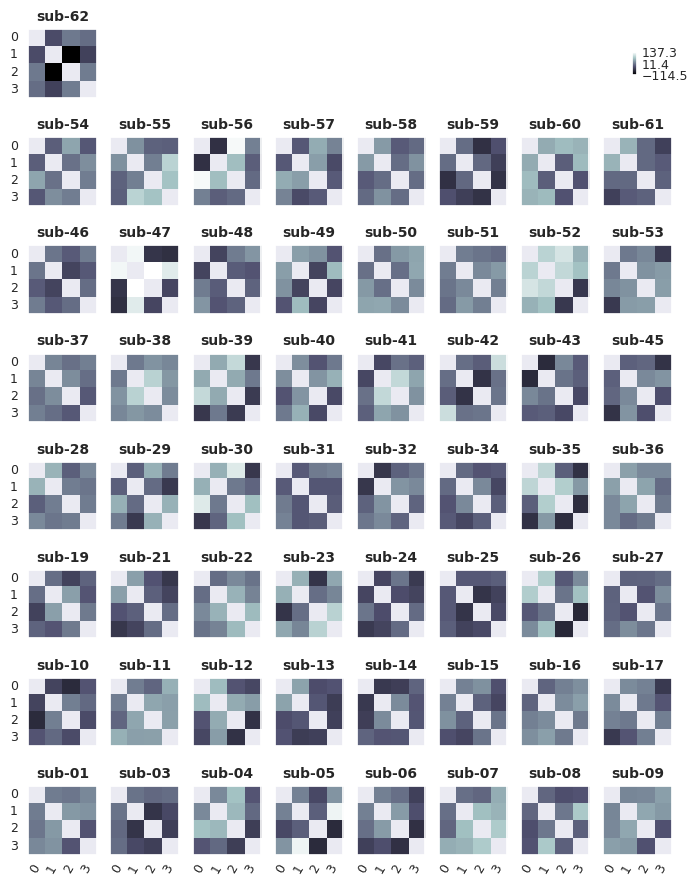

In [197]:
from  rsatoolbox import vis
vis.show_rdm(rdms, rdm_descriptor='subj', show_colorbar='figure', pattern_descriptor='index')

plt.show()

/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/data/u_eperon_software/anaconda3/envs/act_hippo_rsa/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarni

partial rsa pval: Entorhinal-right 0.03688437863959479


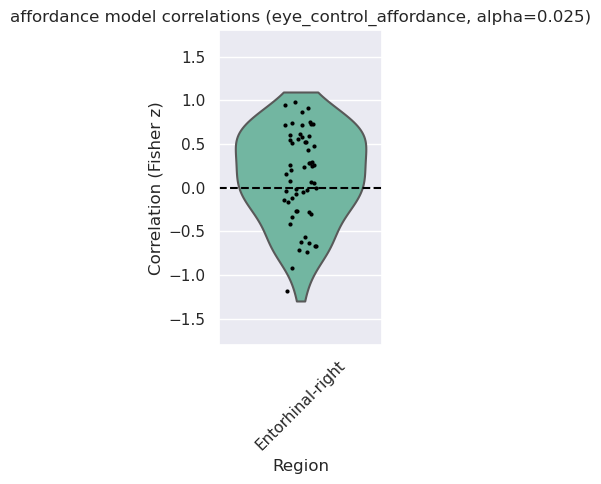

In [198]:
from matplotlib import pyplot as plt
from scipy.stats import ttest_1samp
import seaborn as sns
import numpy as np

sns.set(style='darkgrid')

# clean data
df_plot = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['correlation'])

# use one explicit order everywhere
region_order = list(df_plot['region'].drop_duplicates())
n_regions = len(region_order)

# dynamic figure size (kept relatively thin)
fig_width = min(0.7 * n_regions + 2, 14)
plt.figure(figsize=(fig_width, 5))

# assign a distinct color per region
palette = dict(zip(region_order, sns.color_palette('Set2', n_regions)))

# violin plot
sns.violinplot(
    data=df_plot,
    x='region',
    y='correlation',
    order=region_order,
    palette=palette,
    cut=0.5,
    inner=None
)

# overlay individual data points
sns.stripplot(
    data=df_plot,
    x='region',
    y='correlation',
    order=region_order,
    color='black',
    jitter=True,
    size=3
)

# horizontal zero line
plt.axhline(0, color='black', linestyle='--')

# axis formatting
plt.xticks(rotation=45)
plt.ylim(-1.8, 1.8)
plt.ylabel('Correlation (Fisher z)')
plt.xlabel('Region')

# title = model name (single model case)
plt.title(f'{models[0]} model correlations ({analysis}, alpha=0.025)')

# stats: one-sample t-test against 0
# NOTE: threshold p < 0.025 reflects hemispheric correction
for i, region_ in enumerate(region_order):
    vals = df_plot.loc[df_plot['region'] == region_, 'correlation']

    if len(vals) > 0:
        p = ttest_1samp(vals, 0, alternative='greater')[1]

        if p < 0.025:
            plt.text(i, 1.2, "*", ha='center', va='center',
                     fontsize=16, fontweight='bold')

        print('partial rsa pval:', region_, p)

plt.tight_layout()

plt.savefig(
    f'/data/pt_02747/action_hippo/figures/rdm_correlations_all_regions_{analysis}.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()